In [2]:
import pandas as pd
import numpy as np
import shap

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, make_scorer
from sklearn import tree
from sklearn.preprocessing import LabelEncoder
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# Load Data

## Données artificielles

Dans l'attente des vraies données, je crée des données artificiellement

In [3]:
np.random.seed(0)

# =========================
# 1. PARAMETRES
# =========================

dates = pd.date_range("2021-01-01", "2023-12-31", freq="D")
sites = ["SITE_A", "SITE_B"]

# =========================
# 2. DATA RANDOM
# =========================

df = pd.MultiIndex.from_product(
    [dates, sites],
    names=["date", "code_site"]
).to_frame(index=False)

# pollution
df["O3"] = np.random.uniform(20, 140, len(df))
df["PM10"] = np.random.uniform(10, 80, len(df))

# météo
df["temp"] = np.random.uniform(-5, 35, len(df))
df["vent"] = np.random.uniform(0, 20, len(df))
df["pluie"] = np.random.uniform(0, 10, len(df))

# trafic
df["trafic"] = np.random.uniform(5000, 20000, len(df))

# =========================
# 3. FEATURES POLLUANTS
# =========================

for col in ["O3", "PM10"]:
    df[f"{col}_J"] = df[col]
    df[f"{col}_J-1"] = df.groupby("code_site")[col].shift(1)
    df[f"{col}_J-2"] = df.groupby("code_site")[col].shift(2)
    df[f"{col}_h-24"] = df.groupby("code_site")[col].shift(1)

# =========================
# 4. TARGETS
# =========================

df["Max_O3_J+1"] = df.groupby("code_site")["O3"].shift(-1)
df["Moy_PM10_J+1"] = df.groupby("code_site")["PM10"].shift(-1)

# =========================
# 5. CALENDRIER J+1
# =========================

df["date_J+1"] = df["date"] + pd.Timedelta(days=1)

df["jour_semaine_J+1"] = df["date_J+1"].dt.dayofweek
df["mois_J+1"] = df["date_J+1"].dt.month
df["semaine_J+1"] = df["date_J+1"].dt.isocalendar().week

# =========================
# 6. METEO J+1 (leakage)
# =========================

df["temp_J+1"] = df.groupby("code_site")["temp"].shift(-1)
df["vent_J+1"] = df.groupby("code_site")["vent"].shift(-1)
df["pluie_J+1"] = df.groupby("code_site")["pluie"].shift(-1)

# =========================
# 7. TRAFIC FEATURES
# =========================

df["dow"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month

df["moy_trafic_4jsem"] = (
    df.groupby(["code_site", "dow"])["trafic"]
    .transform(lambda x: x.shift(1).rolling(4).mean())
)

df["moy_trafic_mois"] = (
    df.groupby(["code_site", "month"])["trafic"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

# =========================
# 8. MOYENNE MENSUELLE N-1
# =========================

df["year"] = df["date"].dt.year

monthly = df.groupby(["code_site", "year", "month"])[["O3", "PM10"]].mean().reset_index()
monthly["year"] += 1

monthly = monthly.rename(columns={
    "O3": "moy_O3_mois_N-1",
    "PM10": "moy_PM10_mois_N-1"
})

df = df.merge(monthly, on=["code_site", "year", "month"], how="left")

# =========================
# 9. DATASETS FINAUX
# =========================

df_O3 = df[[
    "date", "code_site",
    "jour_semaine_J+1", "mois_J+1", "semaine_J+1",
    "temp_J+1", "vent_J+1", "pluie_J+1",
    "moy_trafic_4jsem", "moy_trafic_mois",
    "O3_J", "O3_J-1", "O3_J-2", "O3_h-24",
    "moy_O3_mois_N-1",
    "Max_O3_J+1"
]].dropna()

df_PM10 = df[[
    "date", "code_site",
    "jour_semaine_J+1", "mois_J+1", "semaine_J+1",
    "temp_J+1", "vent_J+1", "pluie_J+1",
    "moy_trafic_4jsem", "moy_trafic_mois",
    "PM10_J", "PM10_J-1", "PM10_J-2", "PM10_h-24",
    "moy_PM10_mois_N-1",
    "Moy_PM10_J+1"
]].dropna()

# =========================
# 10. CHECK
# =========================
df_O3.head()

,date,code_site,jour_semaine_J+1,mois_J+1,semaine_J+1,temp_J+1,vent_J+1,pluie_J+1,moy_trafic_4jsem,moy_trafic_mois,O3_J,O3_J-1,O3_J-2,O3_h-24,moy_O3_mois_N-1,Max_O3_J+1
730,2022-01-01,SITE_A,6,1,52,25.635412,18.537328,1.919930,9989.666519,13650.468944,80.127581,111.113894,102.894173,111.113894,78.142433,63.789420
731,2022-01-01,SITE_B,6,1,52,21.302015,12.307263,8.339204,14005.628204,11764.480916,65.166699,63.745355,138.481851,63.745355,82.841335,51.308540
732,2022-01-02,SITE_A,0,1,1,27.827334,11.660873,5.499051,11449.999146,13623.354984,63.789420,80.127581,111.113894,80.127581,78.142433,79.516435
733,2022-01-02,SITE_B,0,1,1,21.719939,7.316542,6.568977,8458.557546,11711.300505,51.308540,65.166699,63.745355,65.166699,82.841335,101.808793
734,2022-01-03,SITE_A,1,1,1,13.077960,19.138472,4.188172,8725.754175,13783.256587,79.516435,63.789420,80.127581,63.789420,78.142433,53.280833


## Vraie données

In [4]:
df_O3 = pd.read_csv("merged_O3_final.csv", sep=",")
df_PM10 = pd.read_csv("merged_pm10_final.csv", sep=",")

In [5]:
df_PM10.isna().sum()

date                                      0
code_site                                 0
target_PM10                               1
avg_debit_Mean_days_last_4_weeks         63
avg_debit_last_15_days                    9
avg_taux_occup_Mean_days_last_4_weeks    63
avg_taux_occup_last_15_days               9
jour_semaine                              0
mois                                      0
numero_semaine                            0
concentration                             0
avg_debit                                 0
avg_taux_occup                            0
RR                                        0
TNTXM                                     0
FFM                                       0
previous_day                              9
previous_2w_mean                          1
next_RR                                   9
next_TNTXM                                9
next_FFM                                  9
dtype: int64

# Preprocessing

In [6]:
df_O3.drop(columns=[
    "avg_debit",
    "avg_taux_occup",    
    ],
    inplace = True
)
df_O3 = df_O3.rename(columns={
    'target_O3': 'Max_O3_J+1',
    'avg_debit_Mean_days_last_4_weeks': 'moy_trafic_4jsem',
    'avg_debit_last_15_days': 'moy_trafic_mois',
    'jour_semaine': 'jour_semaine_J+1',
    'mois': 'mois_J+1',
    'numero_semaine': 'semaine_J+1',
    'concentration':'Max_O3_J',
    'RR':"pluie_J",
    'TNTXM':'temp_J',
    'FFM':'vent_J',
    'previous_day':'Max_O3_J_1',
    'previous_2w_mean':'avg_max_O3_last_2w',
    'next_RR':'pluie_J+1',
    'next_TNTXM':'temp_J+1',
    'next_FFM':'vent_J+1'
})
df_O3["date"] = pd.to_datetime(df_O3["date"])
print(f"Dans df_O3, Les dates {df_O3[df_O3["moy_trafic_4jsem"].isna()]["date"].unique().tolist()} ont été retirées car certaines features basées sur des données du passé ou du futur ne peuvent pas être calculées à ces dates là")
df_O3.dropna(subset=["moy_trafic_4jsem", "pluie_J+1"], inplace=True)

df_PM10.drop(columns=[
    "avg_debit",
    "avg_taux_occup",    
    ],
    inplace = True
)
df_PM10 = df_PM10.rename(columns={
    'target_PM10': 'Moy_PM10_J+1',
    'avg_debit_Mean_days_last_4_weeks': 'moy_trafic_4jsem',
    'avg_debit_last_15_days': 'moy_trafic_mois',
    'jour_semaine': 'jour_semaine_J+1',
    'mois': 'mois_J+1',
    'numero_semaine': 'semaine_J+1',
    'concentration':'Moy_PM10_J',
    'RR':"pluie_J",
    'TNTXM':'temp_J',
    'FFM':'vent_J',
    'previous_day':'Moy_PM10_J_1',
    'previous_2w_mean':'avg_moy_PM10_last_2w',
    'next_RR':'pluie_J+1',
    'next_TNTXM':'temp_J+1',
    'next_FFM':'vent_J+1'
})
df_PM10["date"] = pd.to_datetime(df_PM10["date"])
print(f"Dans df_PM10, Les dates {df_PM10[df_PM10["moy_trafic_4jsem"].isna()]["date"].unique().tolist()} ont été retirées car certaines features basées sur des données du passé ou du futur ne peuvent pas être calculées à ces dates là")
df_PM10.dropna(subset=["moy_trafic_4jsem", "pluie_J+1"], inplace=True)

SyntaxError: f-string: unmatched '[' (2042575946.py, line 25)

# Feature Engineering

## Transformation de la target en variable binaire

In [ ]:
SEUIL_O3 = 130
SEUIL_PM10 = 50

df_O3['y'] = (df_O3['Max_O3_J+1'] > SEUIL_O3).astype(int)
df_PM10['y'] = (df_PM10['Moy_PM10_J+1'] > SEUIL_PM10).astype(int)

nb_lignes_O3 = len(df_O3.axes[0])
nb_pics_O3 = df_O3['y'].sum()
nb_non_pics_O3 = nb_lignes_O3 - nb_pics_O3
perc_pics_O3 = 100 * (nb_pics_O3 / nb_lignes_O3)

nb_lignes_PM10 = len(df_O3.axes[0])
nb_pics_PM10 = df_PM10['y'].sum()
nb_non_pics_PM10 = nb_lignes_PM10 - nb_pics_PM10
perc_pics_PM10 = 100 * (nb_pics_PM10 / nb_lignes_PM10)

print(f"Pour O3 entre 2021 et 2023, il y a {nb_pics_O3} pics VS {nb_non_pics_O3} non-pics, soit {np.round(perc_pics_O3, 2)}% de pics")
print(f"Pour PM10 entre 2021 et 2023, il y a {nb_pics_PM10} pics VS {nb_non_pics_PM10} non-pics, soit {np.round(perc_pics_PM10, 2)}% de pics")

Pour O3 entre 2021 et 2023, il y a 146 pics VS 4178 non-pics, soit 3.38% de pics
Pour PM10 entre 2021 et 2023, il y a 238 pics VS 4086 non-pics, soit 5.5% de pics


## Encodage des variables caétégorielles

Certains modèles comme la régression logistique ne fonctionnent pas avec des variables catégorielles

In [ ]:
le = LabelEncoder()
df_O3["code_site_enc"] = le.fit_transform(df_O3["code_site"])
df_PM10["code_site_enc"] = le.fit_transform(df_PM10["code_site"])

## Selection des features

In [ ]:
features_O3 = [col for col in df_O3.columns if col not in ['date', 'Max_O3_J+1', 'code_site', 'y']]
features_PM10 = [col for col in df_PM10.columns if col not in ['date', 'Moy_PM10_J+1', 'code_site', 'y']]

# Train Test Split temporel (2021-2022 VS 2023)

In [ ]:
train_O3 = df_O3[df_O3['date'].dt.year.isin([2021, 2022])]
test_O3  = df_O3[df_O3['date'].dt.year == 2023]

X_train_O3 = train_O3[features_O3]
y_train_O3 = train_O3['y']
X_test_O3  = test_O3[features_O3]
y_test_O3  = test_O3['y']

train_PM10 = df_PM10[df_PM10['date'].dt.year.isin([2021, 2022])]
test_PM10  = df_PM10[df_PM10['date'].dt.year == 2023]

X_train_PM10 = train_PM10[features_PM10]
y_train_PM10 = train_PM10['y']
X_test_PM10  = test_PM10[features_PM10]
y_test_PM10  = test_PM10['y']

# Decision Tree

On commence par un arbre de décision tout simple pour visualiser les features qui influencent le modèle

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(
        random_state=42,
        max_depth=10
        ))
])

## Train & Predict

In [ ]:
pipeline_O3 = clone(pipeline)
pipeline_PM10 = clone(pipeline)

pipeline_O3.fit(X_train_O3, y_train_O3)
pipeline_PM10.fit(X_train_PM10, y_train_PM10)

clf_O3 = pipeline_O3.named_steps['clf']
clf_PM10 = pipeline_PM10.named_steps['clf']

y_pred_O3 = pipeline_O3.predict(X_test_O3)
y_pred_PM10 = pipeline_PM10.predict(X_test_PM10)

In [ ]:
# O3
recall_O3 = recall_score(y_test_O3, y_pred_O3, pos_label=1)
precision_O3 = precision_score(y_test_O3, y_pred_O3, pos_label=1)
f1_O3 = f1_score(y_test_O3, y_pred_O3, pos_label=1)

print(f"O3 - Recall classe positive (pics) : {recall_O3:.2f}")
print(f"O3 - Precision classe positive (pics) : {precision_O3:.2f}")
print(f"O3 - f1-score classe positive (pics) : {f1_O3:.2f}\n")

# PM10
recall_PM10 = recall_score(y_test_PM10, y_pred_PM10, pos_label=1)
precision_PM10 = precision_score(y_test_PM10, y_pred_PM10, pos_label=1)
f1_PM10 = f1_score(y_test_PM10, y_pred_PM10, pos_label=1)

print(f"PM10 - Recall classe positive (pics) : {recall_PM10:.2f}")
print(f"PM10 - Precision classe positive (pics) : {precision_PM10:.2f}")
print(f"PM10 - f1-score classe positive (pics) : {f1_PM10:.2f}\n")

O3 - Recall classe positive (pics) : 0.27
O3 - Precision classe positive (pics) : 0.39
O3 - f1-score classe positive (pics) : 0.32

PM10 - Recall classe positive (pics) : 0.48
PM10 - Precision classe positive (pics) : 0.38
PM10 - f1-score classe positive (pics) : 0.43



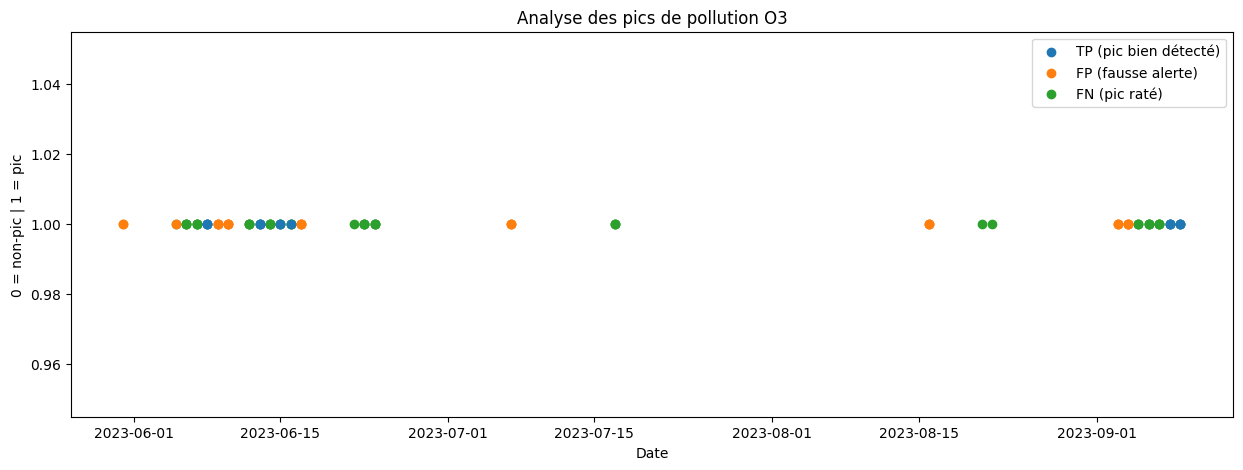

In [ ]:
df_plot = test_O3.copy().reset_index(drop=True)
df_plot["y_pred"] = y_pred_O3

df_plot = df_plot.sort_values("date")

# Conditions
tp = (df_plot["y"] == 1) & (df_plot["y_pred"] == 1)
fp = (df_plot["y"] == 0) & (df_plot["y_pred"] == 1)
fn = (df_plot["y"] == 1) & (df_plot["y_pred"] == 0)

plt.figure(figsize=(15,5))

# TP
plt.scatter(df_plot.loc[tp, "date"],
            df_plot.loc[tp, "y"],
            label="TP (pic bien détecté)",
            zorder=3
            )

plt.scatter(df_plot.loc[fp, "date"],
            df_plot.loc[fp, "y_pred"],
            label="FP (fausse alerte)",
            zorder=2
            )

plt.scatter(df_plot.loc[fn, "date"],
            df_plot.loc[fn, "y"],
            label="FN (pic raté)",
            zorder=1
            )

plt.legend()
plt.title("Analyse des pics de pollution O3")
plt.xlabel("Date")
plt.ylabel("0 = non-pic | 1 = pic")

plt.show()

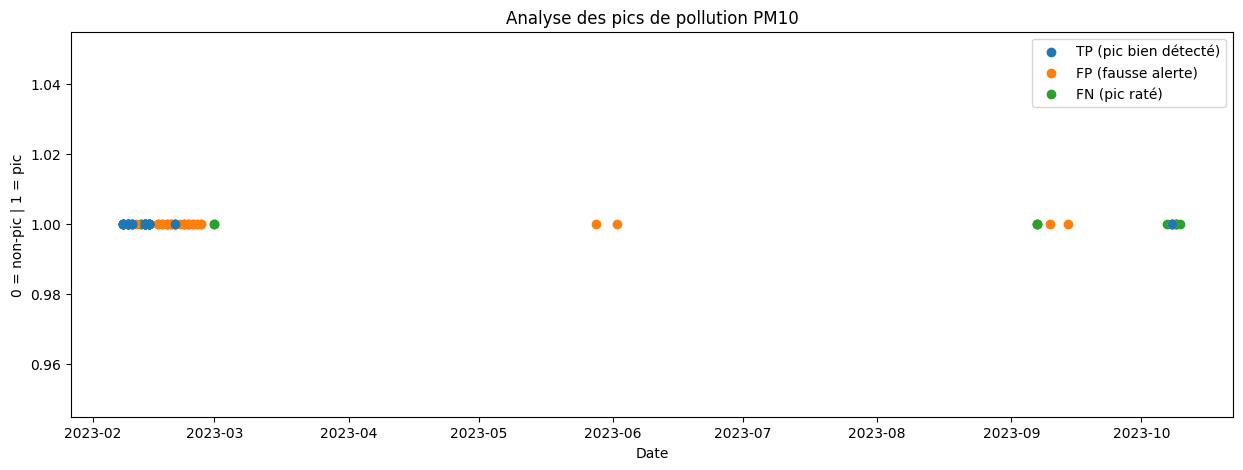

In [ ]:
df_plot = test_PM10.copy().reset_index(drop=True)
df_plot["y_pred"] = y_pred_PM10

df_plot = df_plot.sort_values("date")

# Conditions
tp = (df_plot["y"] == 1) & (df_plot["y_pred"] == 1)
fp = (df_plot["y"] == 0) & (df_plot["y_pred"] == 1)
fn = (df_plot["y"] == 1) & (df_plot["y_pred"] == 0)

plt.figure(figsize=(15,5))

# TP
plt.scatter(df_plot.loc[tp, "date"],
            df_plot.loc[tp, "y"],
            label="TP (pic bien détecté)",
            zorder=3
            )

plt.scatter(df_plot.loc[fp, "date"],
            df_plot.loc[fp, "y_pred"],
            label="FP (fausse alerte)",
            zorder=2
            )

plt.scatter(df_plot.loc[fn, "date"],
            df_plot.loc[fn, "y"],
            label="FN (pic raté)",
            zorder=1
            )

plt.legend()
plt.title("Analyse des pics de pollution PM10")
plt.xlabel("Date")
plt.ylabel("0 = non-pic | 1 = pic")

plt.show()

Arbre pour O3


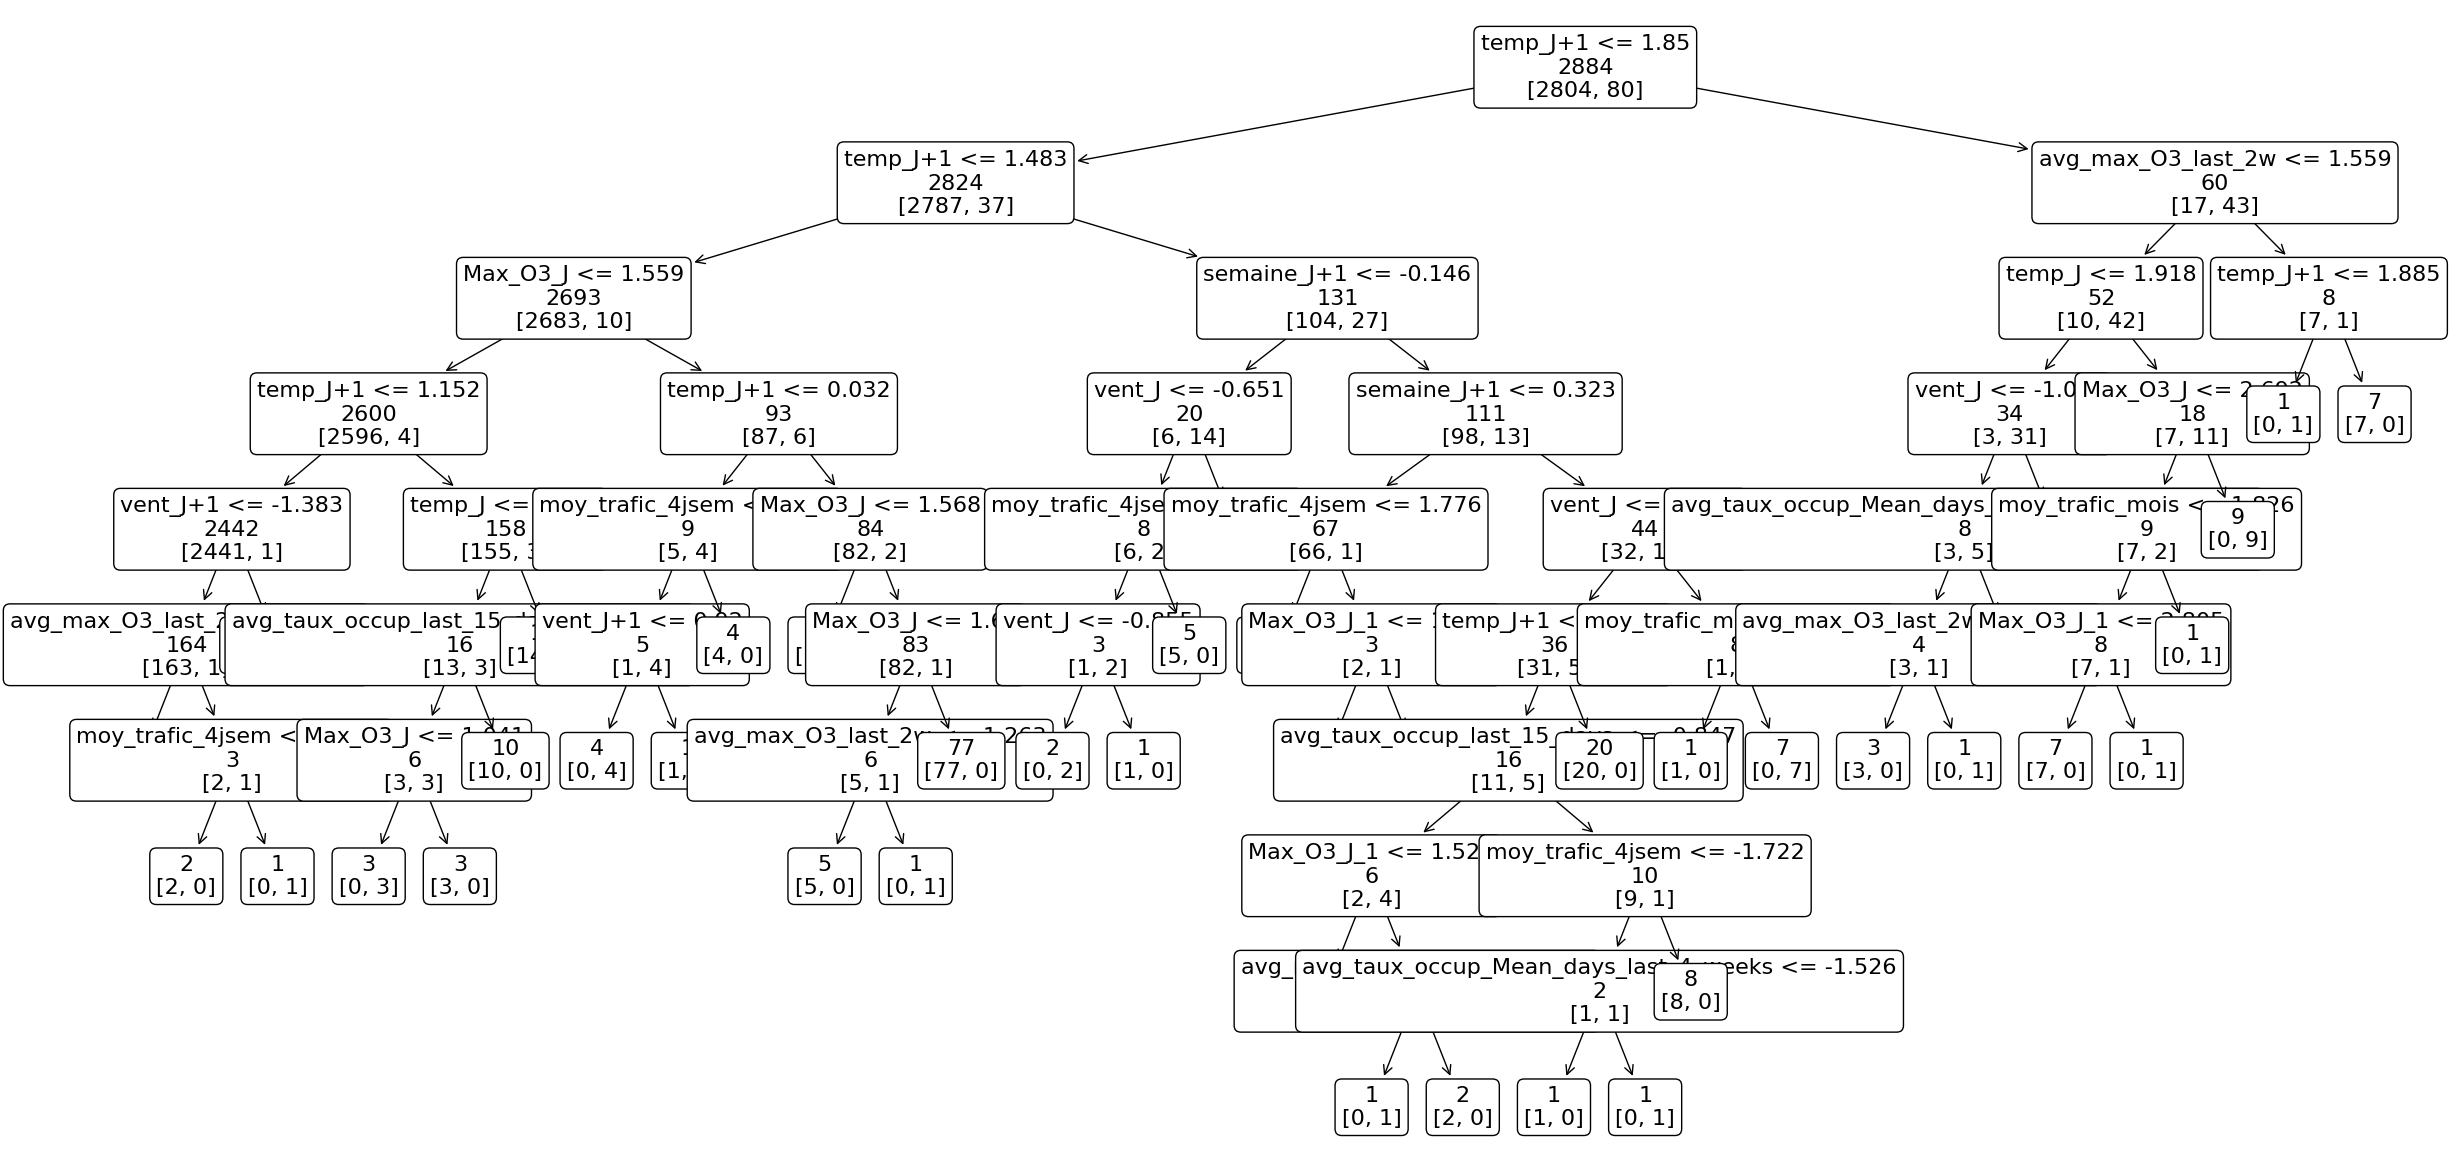

In [ ]:
plt.figure(figsize=(30,15))  # plus grand
tree.plot_tree(
    clf_O3,
    feature_names=features_O3,
    filled=False,
    rounded=True,
    impurity=False,
    label='none',
    fontsize=16   # 👈 augmente ici
)
print("Arbre pour O3")
plt.show()

arbre pour PM10


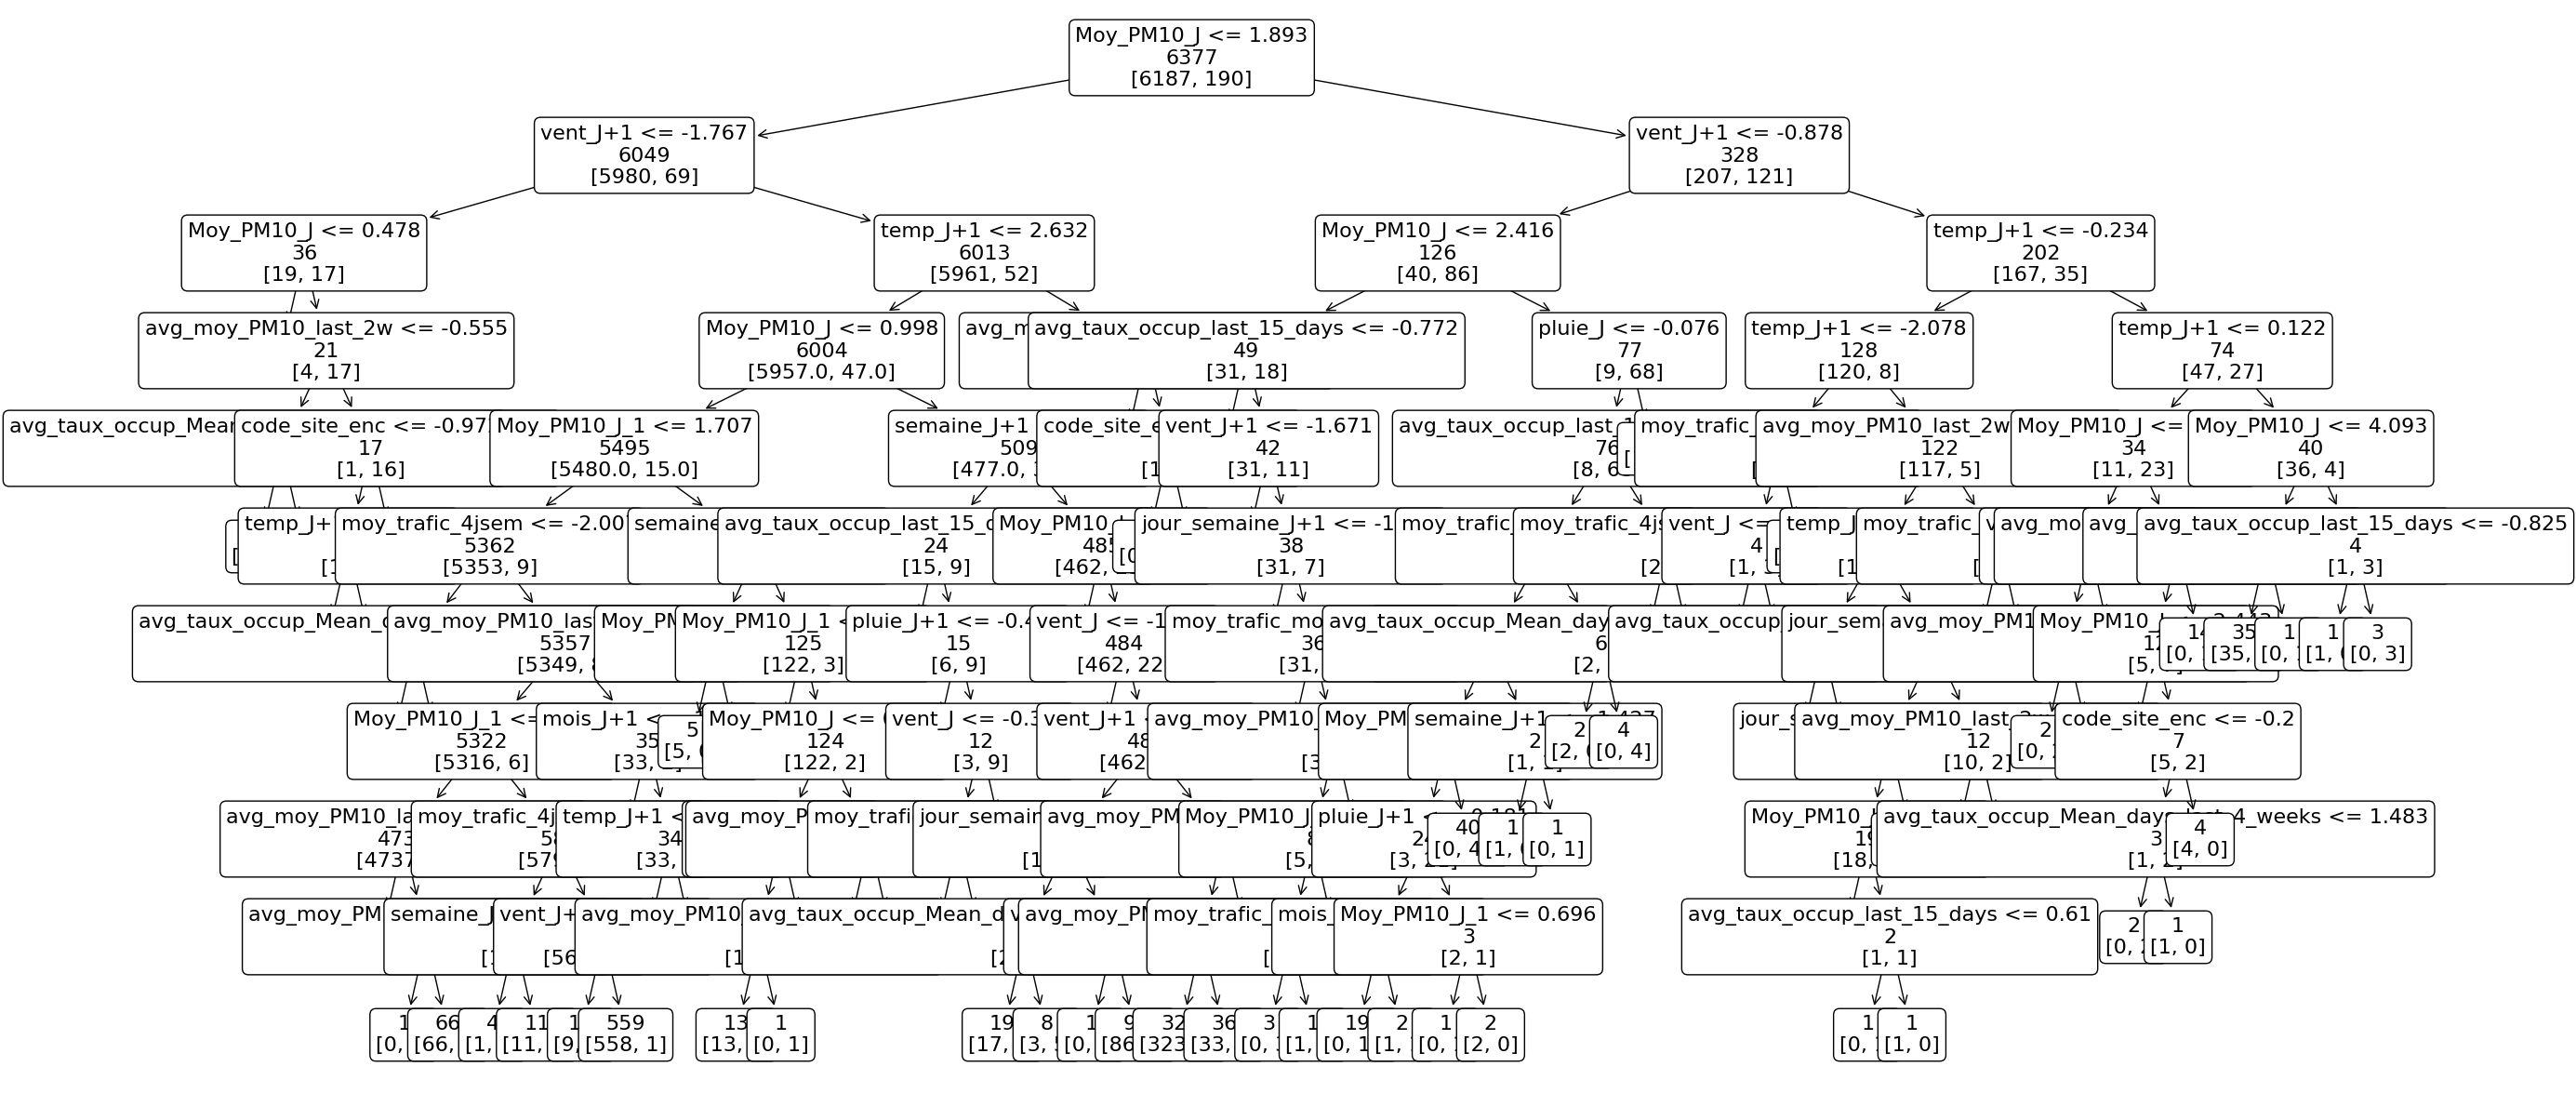

In [ ]:
plt.figure(figsize=(30,15))
tree.plot_tree(
    clf_PM10,
    feature_names=features_PM10,
    filled=False,
    rounded=True,
    impurity=False,
    label='none',
    fontsize=16
)
print("arbre pour PM10")
plt.show()

# Comparaison multi-modèles

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

{'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}
def evaluate_models(X_train, y_train, X_test, y_test):
    
    results = []
    
    for name, model in models.items():
        
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results.append({
            "model": name,
            "recall_pic": recall,
            "precision_pic": precision,
            "f1_score": f1
        })
    
    return pd.DataFrame(results).sort_values("f1_score", ascending=False)

# RUN
results_O3 = evaluate_models(X_train_O3, y_train_O3, X_test_O3, y_test_O3)
results_PM10 = evaluate_models(X_train_PM10, y_train_PM10, X_test_PM10, y_test_PM10)

print("=== O3 ===")
print(results_O3)

print("\n=== PM10 ===")
print(results_PM10)

c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:32:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:32:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== O3 ===
                 model  recall_pic  precision_pic  f1_score
0  Logistic Regression    0.393939       0.742857  0.514851
3        Random Forest    0.348485       0.766667  0.479167
4              XGBoost    0.287879       0.655172  0.400000
2                  SVM    0.196970       1.000000  0.329114
1        Decision Tree    0.272727       0.391304  0.321429

=== PM10 ===
                 model  recall_pic  precision_pic  f1_score
4              XGBoost    0.520833       0.757576  0.617284
0  Logistic Regression    0.500000       0.648649  0.564706
1        Decision Tree    0.479167       0.383333  0.425926
3        Random Forest    0.270833       0.928571  0.419355
2                  SVM    0.208333       0.909091  0.338983


A ce stade, les performances sont mauvaises quelque soit le modèle

# Gestion du déséquilibre

Nos données sont très déséquilibrées : ~3% et ~5% de classe positive resp. pour O3 et PM10.
Explorons différentes méthodes pour gérer ce déséquilibre et ainsi tenter d'améliorer les performances du modèle. 

## Undersampling

In [ ]:
def undersample(df, target_col):
    df_pos = df[df[target_col] == 1]
    df_neg = df[df[target_col] == 0]
    df_neg_sampled = df_neg.sample(n=len(df_pos), random_state=42)
    df_balanced = pd.concat([df_pos, df_neg_sampled])
    return df_balanced.sample(frac=1, random_state=42)

train_O3_balanced = undersample(train_O3, 'y')
X_train_O3_bal = train_O3_balanced[features_O3]
y_train_O3_bal = train_O3_balanced['y']
print(f"taille du dataset O3 avant le sampling : {len(train_O3.axes[0])} lignes")
print(f"taille du dataset O3 après  le sampling : {len(train_O3_balanced.axes[0])} lignes")

train_PM10_balanced = undersample(train_PM10, 'y')
X_train_PM10_bal = train_PM10_balanced[features_PM10]
y_train_PM10_bal = train_PM10_balanced['y']
print(f"taille du dataset PM10 avant le sampling : {len(train_PM10.axes[0])} lignes")
print(f"taille du dataset PM10 après  le sampling : {len(train_PM10_balanced.axes[0])} lignes")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

def evaluate_models(X_train, y_train, X_test, y_test):
    
    results = []
    
    for name, model in models.items():
        
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results.append({
            "model": name,
            "recall_pic": recall,
            "precision_pic": precision,
            "f1_score": f1
        })
    
    return pd.DataFrame(results).sort_values("f1_score", ascending=False)

results_O3 = evaluate_models(X_train_O3_bal, y_train_O3_bal, X_test_O3, y_test_O3)
results_PM10 = evaluate_models(X_train_PM10_bal, y_train_PM10_bal, X_test_PM10, y_test_PM10)

print("=== O3 ===")
print(results_O3)

print("\n=== PM10 ===")
print(results_PM10)

taille du dataset O3 avant le sampling : 2884 lignes
taille du dataset O3 après  le sampling : 160 lignes
taille du dataset PM10 avant le sampling : 6377 lignes
taille du dataset PM10 après  le sampling : 380 lignes


c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:32:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== O3 ===
                 model  recall_pic  precision_pic  f1_score
4              XGBoost    0.863636       0.337278  0.485106
0  Logistic Regression    0.939394       0.314721  0.471483
3        Random Forest    0.939394       0.313131  0.469697
1        Decision Tree    0.939394       0.289720  0.442857
2                  SVM    0.954545       0.260331  0.409091

=== PM10 ===
                 model  recall_pic  precision_pic  f1_score
3        Random Forest    0.958333       0.282209  0.436019
4              XGBoost    0.916667       0.282051  0.431373
2                  SVM    0.875000       0.269231  0.411765
0  Logistic Regression    0.958333       0.220096  0.357977
1        Decision Tree    0.937500       0.185950  0.310345


c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:32:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Analyse : Bien que le recall s'améliore considérablement (39% VS 86% pour O3 et 52% VS 95%), la précision est elle bien dégradée 33% et 28% après VS 74% et 75% avant, ce qui résulte en une dégradation du f1-score 51% et 61% avant, 48% et 43% maintenant.
Cette méthode permet donc de rater moins de pics mais dégrade la qualité de nos alertes car beaucoup de fausses alertes. Cela s'explique par le changement de distribution des données : avant, le modèle penchait naturellement vers la classe négative et donc osait moins prédire la classe positive, d'où un recall faible et une précision élevé. Maintenant, il ose + prédire la classe positive car elle n'est plus minoritaire donc il capte mieux les pics mais se trompe. De plus, cette méthode est limitée par la petite taille de notre dataset de base ce qui rend le dataset résultant du sampling très petit

## Pondération des classes

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, class_weight="balanced", random_state=42),
    "SVM": SVC(probability=True, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
    
    # XGBoost ne prend pas class_weight directement
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight = (len(y_train_O3) - sum(y_train_O3)) / sum(y_train_O3)
    )
}

def evaluate_models(X_train, y_train, X_test, y_test):
    
    results = []
    
    for name, model in models.items():
        
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results.append({
            "model": name,
            "recall_pic": recall,
            "precision_pic": precision,
            "f1_score": f1
        })
    
    return pd.DataFrame(results).sort_values("f1_score", ascending=False)

# RUN
results_O3 = evaluate_models(X_train_O3, y_train_O3, X_test_O3, y_test_O3)
results_PM10 = evaluate_models(X_train_PM10, y_train_PM10, X_test_PM10, y_test_PM10)

print("=== O3 ===")
print(results_O3)

print("\n=== PM10 ===")
print(results_PM10)

c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:32:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:32:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== O3 ===
                 model  recall_pic  precision_pic  f1_score
2                  SVM    0.621212       0.455556  0.525641
0  Logistic Regression    0.939394       0.356322  0.516667
4              XGBoost    0.363636       0.648649  0.466019
1        Decision Tree    0.333333       0.323529  0.328358
3        Random Forest    0.045455       0.375000  0.081081

=== PM10 ===
                 model  recall_pic  precision_pic  f1_score
4              XGBoost    0.625000       0.697674  0.659341
2                  SVM    0.666667       0.438356  0.528926
1        Decision Tree    0.520833       0.301205  0.381679
0  Logistic Regression    0.916667       0.231579  0.369748
3        Random Forest    0.229167       0.846154  0.360656


**ANALYSE**

Cette méthode améliore légèrement les f1-score

## Surpondération simple

In [ ]:
def oversample(df, target_col):
    df_pos = df[df[target_col] == 1]
    df_neg = df[df[target_col] == 0]
    df_pos_sampled = df_pos.sample(n=len(df_neg), replace=True, random_state=42)
    df_balanced = pd.concat([df_neg, df_pos_sampled])
    return df_balanced.sample(frac=1, random_state=42)

train_O3_oversampled = oversample(train_O3, 'y')
X_train_O3_oversampled = train_O3_oversampled[features_O3]
y_train_O3_oversampled = train_O3_oversampled['y']
print(f"taille du dataset O3 avant le sampling : {len(train_O3.axes[0])} lignes")
print(f"taille du dataset O3 après  le sampling : {len(train_O3_oversampled.axes[0])} lignes")

train_PM10_oversampled = oversample(train_PM10, 'y')
X_train_PM10_oversampled = train_PM10_oversampled[features_PM10]
y_train_PM10_oversampled = train_PM10_oversampled['y']
print(f"taille du dataset PM10 avant le sampling : {len(train_PM10.axes[0])} lignes")
print(f"taille du dataset PM10 après  le sampling : {len(train_PM10_oversampled.axes[0])} lignes")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

def evaluate_models(X_train, y_train, X_test, y_test):
    
    results = []
    
    for name, model in models.items():
        
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results.append({
            "model": name,
            "recall_pic": recall,
            "precision_pic": precision,
            "f1_score": f1
        })
    
    return pd.DataFrame(results).sort_values("f1_score", ascending=False)

results_O3 = evaluate_models(X_train_O3_bal, y_train_O3_bal, X_test_O3, y_test_O3)
results_PM10 = evaluate_models(X_train_PM10_bal, y_train_PM10_bal, X_test_PM10, y_test_PM10)

print("=== O3 ===")
print(results_O3)

print("\n=== PM10 ===")
print(results_PM10)

taille du dataset O3 avant le sampling : 2884 lignes
taille du dataset O3 après  le sampling : 5608 lignes
taille du dataset PM10 avant le sampling : 6377 lignes
taille du dataset PM10 après  le sampling : 12374 lignes


c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:32:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== O3 ===
                 model  recall_pic  precision_pic  f1_score
4              XGBoost    0.863636       0.337278  0.485106
0  Logistic Regression    0.939394       0.314721  0.471483
3        Random Forest    0.939394       0.313131  0.469697
1        Decision Tree    0.939394       0.289720  0.442857
2                  SVM    0.954545       0.260331  0.409091

=== PM10 ===
                 model  recall_pic  precision_pic  f1_score
3        Random Forest    0.958333       0.282209  0.436019
4              XGBoost    0.916667       0.282051  0.431373
2                  SVM    0.875000       0.269231  0.411765
0  Logistic Regression    0.958333       0.220096  0.357977
1        Decision Tree    0.937500       0.185950  0.310345


c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:32:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# Pas de normalisation

Jusque ici, les données étaient normalisées, notamment pour la régression logistique et le SVM. On suppose généralement que ça change rien pour les modèles à base d'arbre : vérifions !

In [ ]:
models = {
    # "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    # "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

def evaluate_models(X_train, y_train, X_test, y_test):
    
    results = []
    
    for name, model in models.items():
        
        pipeline = Pipeline([
            ('model', model)
        ])
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results.append({
            "model": name,
            "recall_pic": recall,
            "precision_pic": precision,
            "f1_score": f1
        })
    
    return pd.DataFrame(results).sort_values("f1_score", ascending=False)

# RUN
results_O3 = evaluate_models(X_train_O3, y_train_O3, X_test_O3, y_test_O3)
results_PM10 = evaluate_models(X_train_PM10, y_train_PM10, X_test_PM10, y_test_PM10)

print("=== O3 ===")
print(results_O3)

print("\n=== PM10 ===")
print(results_PM10)

c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:32:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:32:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== O3 ===
           model  recall_pic  precision_pic  f1_score
1  Random Forest    0.363636       0.827586  0.505263
2        XGBoost    0.287879       0.655172  0.400000
0  Decision Tree    0.242424       0.363636  0.290909

=== PM10 ===
           model  recall_pic  precision_pic  f1_score
2        XGBoost    0.520833       0.757576  0.617284
0  Decision Tree    0.479167       0.377049  0.422018
1  Random Forest    0.270833       0.928571  0.419355


Analyse : C'est mieux pour Random Forest, pareil pour XGBooost et moins bien pour DT

# Hyperopt

## Grid search (ça prend du temps à tourner)

In [ ]:
# models = {
#     "Logistic Regression": LogisticRegression(max_iter=1000),
#     "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
#     "SVM": SVC(probability=True),
#     "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
#     "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
# }

# param_grids = {

#     "Logistic Regression": {
#         "model__C": [0.01, 0.1, 1, 10],
#         "model__penalty": ["l2"],
#         "model__solver": ["lbfgs"]
#     },

#     "Decision Tree": {
#         "model__max_depth": [3, 5, 10, 20],
#         "model__min_samples_split": [2, 5, 10],
#         "model__min_samples_leaf": [1, 2, 5]
#     },

#     "SVM": {
#         "model__C": [0.1, 1, 10],
#         "model__kernel": ["rbf", "linear"],
#         "model__gamma": ["scale", "auto"]
#     },

#     "Random Forest": {
#         "model__n_estimators": [100, 200],
#         "model__max_depth": [5, 10, None],
#         "model__min_samples_split": [2, 5]
#     },

#     "XGBoost": {
#         "model__n_estimators": [100, 200],
#         "model__max_depth": [3, 5, 7],
#         "model__learning_rate": [0.01, 0.1],
#         "model__subsample": [0.8, 1.0]
#     }
# }

# def run_grid_search(X_train, y_train, models, param_grids):

#     results = []

#     scorer = make_scorer(f1_score)

#     for name, model in models.items():

#         print(f"Running GridSearch for {name}...")

#         pipeline = Pipeline([
#             ("scaler", StandardScaler()),
#             ("model", model)
#         ])

#         grid = GridSearchCV(
#             pipeline,
#             param_grids[name],
#             scoring=scorer,
#             cv=3,
#             n_jobs=-1,
#             verbose=1
#         )

#         grid.fit(X_train, y_train)

#         best_model = grid.best_estimator_

#         results.append({
#             "model": name,
#             "best_score": grid.best_score_,
#             "best_params": grid.best_params_,
#             "best_estimator": best_model
#         })

#     return results

# grid_results_O3 = run_grid_search(X_train_O3, y_train_O3, models, param_grids)
# grid_results_PM10 = run_grid_search(X_train_PM10, y_train_PM10, models, param_grids)

In [ ]:
# for r in grid_results_O3:
#     print("=== O3 ===")
#     print(r["model"])
#     print("Best F1:", r["best_score"])
#     print("Best params:", r["best_params"])
#     print()

In [ ]:
# for r in grid_results_PM10:
#     print("=== PM10 ===")
#     print(r["model"])
#     print("Best F1:", r["best_score"])
#     print("Best params:", r["best_params"])
#     print()

In [ ]:
models = {
    # "Logistic Regression": LogisticRegression(max_iter=1000),
    # "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    # "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_split=5,
        random_state=42
        ),
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss')
}

def evaluate_models(X_train, y_train, X_test, y_test):
    
    results = []
    
    for name, model in models.items():
        
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results.append({
            "model": name,
            "recall_pic": recall,
            "precision_pic": precision,
            "f1_score": f1
        })
    
    return pd.DataFrame(results).sort_values("f1_score", ascending=False)

# RUN
results_O3 = evaluate_models(X_train_O3, y_train_O3, X_test_O3, y_test_O3)
results_PM10 = evaluate_models(X_train_PM10, y_train_PM10, X_test_PM10, y_test_PM10)

print("=== O3 ===")
print(results_O3)

print("\n=== PM10 ===")
print(results_PM10)

c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:32:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:32:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== O3 ===
           model  recall_pic  precision_pic  f1_score
1        XGBoost    0.287879       0.655172  0.400000
0  Random Forest    0.257576       0.772727  0.386364

=== PM10 ===
           model  recall_pic  precision_pic  f1_score
1        XGBoost    0.520833       0.757576  0.617284
0  Random Forest    0.270833       0.866667  0.412698


Hyperopt des MVP

In [ ]:
O3_best_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
}

THRESHOLD_O3 = 0.2

def evaluate_models(X_train, y_train, X_test, y_test):
    
    results = []
    for name, model in O3_best_models.items():
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        pipeline.fit(X_train, y_train)
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= THRESHOLD_O3).astype(int)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results.append({
            "model": name,
            "threshold": THRESHOLD_O3,
            "recall_pic": recall,
            "precision_pic": precision,
            "f1_score": f1
        })
    
    return pd.DataFrame(results).sort_values("f1_score", ascending=False)

# RUN
best_results_O3 = evaluate_models(X_train_O3, y_train_O3, X_test_O3, y_test_O3)
print("=== O3 ===")
print(best_results_O3)


=== O3 ===
                 model  threshold  recall_pic  precision_pic  f1_score
0  Logistic Regression        0.2     0.80303       0.679487  0.736111


In [ ]:
PM10_best_models = {
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=(len(y_train_O3) - sum(y_train_O3)) / sum(y_train_O3),

        learning_rate=0.3,
        max_depth=6,
        n_estimators=100,
        subsample=1
)}

THRESHOLD_PM10 = 0.6

def evaluate_models(X_train, y_train, X_test, y_test):
    
    results = []
    for name, model in PM10_best_models.items():
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        pipeline.fit(X_train, y_train)
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= THRESHOLD_PM10).astype(int)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        results.append({
            "model": name,
            "threshold": THRESHOLD_PM10,
            "recall_pic": recall,
            "precision_pic": precision,
            "f1_score": f1
        })
    
    return pd.DataFrame(results).sort_values("f1_score", ascending=False)

# RUN
best_results_PM10 = evaluate_models(X_train_PM10, y_train_PM10, X_test_PM10, y_test_PM10)
print("=== O3 ===")
print(best_results_PM10)


c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:09:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== O3 ===
     model  threshold  recall_pic  precision_pic  f1_score
0  XGBoost        0.6    0.604167       0.763158  0.674419


In [ ]:
THRESHOLD = 0.2

# 🔑 Scorer custom avec seuil 0.2
def f1_at_threshold(y_true, y_proba):
    y_pred = (y_proba >= THRESHOLD).astype(int)
    return f1_score(y_true, y_pred)

custom_scorer = make_scorer(f1_at_threshold, needs_proba=True)

# Modèle unique
model = LogisticRegression(max_iter=1000)

# Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", model)
])

# Grid
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

# GridSearch
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring=custom_scorer,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# 🔥 TRAIN uniquement sur O3
grid.fit(X_train_O3, y_train_O3)

best_model = grid.best_estimator_

print("Best params:", grid.best_params_)
print("Best CV score (F1 @ 0.2):", grid.best_score_)

c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params: {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV score (F1 @ 0.2): 0.6019209039548022


In [ ]:
y_proba = best_model.predict_proba(X_test_O3)[:, 1]
y_pred = (y_proba >= THRESHOLD).astype(int)

print("Precision:", precision_score(y_test_O3, y_pred))
print("Recall:", recall_score(y_test_O3, y_pred))
print("F1:", f1_score(y_test_O3, y_pred))

Precision: 0.6794871794871795
Recall: 0.803030303030303
F1: 0.7361111111111112


In [ ]:
THRESHOLD = 0.6

# 🔑 Scorer custom
def f1_at_threshold(y_true, y_proba):
    y_pred = (y_proba >= THRESHOLD).astype(int)
    return f1_score(y_true, y_pred)

custom_scorer = make_scorer(f1_at_threshold, needs_proba=True)

# Modèle XGBoost
model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight = (len(y_train_PM10) - sum(y_train_PM10)) / sum(y_train_PM10),
    random_state=42
)

# ⚠️ scaler inutile pour XGBoost, mais on peut le laisser pour homogénéité pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", model)
])

# Grid raisonnable (évite explosion)
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1],
    "model__subsample": [0.8, 1.0]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring=custom_scorer,
    cv=3,
    n_jobs=-1,
    verbose=1
)

# 🔥 TRAIN uniquement sur PM10
grid.fit(X_train_PM10, y_train_PM10)

best_model = grid.best_estimator_

print("Best params:", grid.best_params_)
print("Best CV score (F1 @ 0.6):", grid.best_score_)

c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


Fitting 3 folds for each of 24 candidates, totalling 72 fits


c:\Users\romai\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:45:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV score (F1 @ 0.6): 0.7711640211640213


In [ ]:
y_proba = best_model.predict_proba(X_test_PM10)[:, 1]
y_pred = (y_proba >= THRESHOLD).astype(int)

print("Precision:", precision_score(y_test_PM10, y_pred))
print("Recall:", recall_score(y_test_PM10, y_pred))
print("F1:", f1_score(y_test_PM10, y_pred))

Precision: 0.717948717948718
Recall: 0.5833333333333334
F1: 0.6436781609195402


# Explicabilité

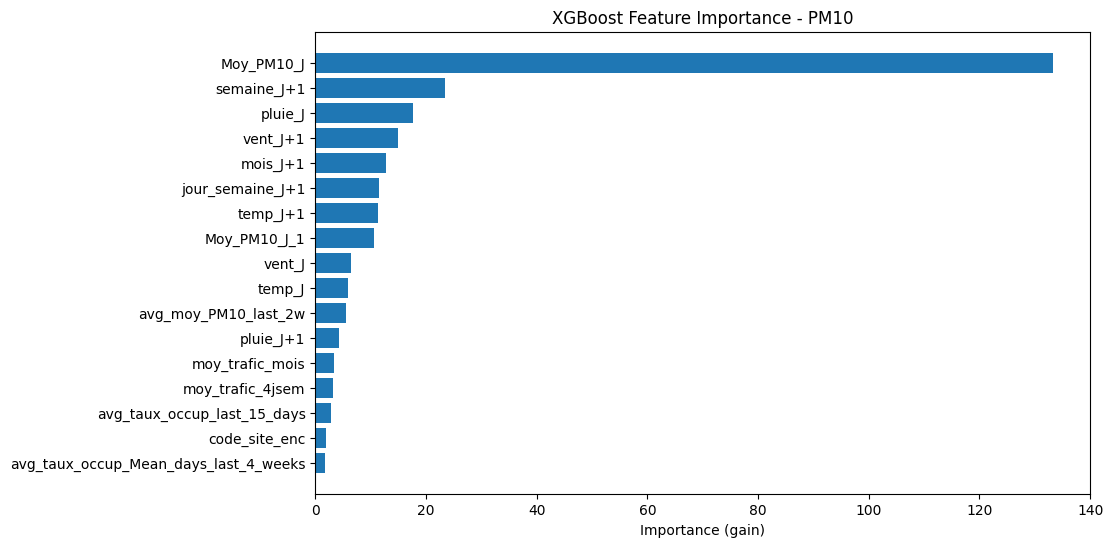

In [ ]:
# récupérer importance
booster = model.get_booster()
importance_dict = booster.get_score(importance_type='gain')

# mapping f0, f1... → noms des colonnes
feature_names = X_train_PM10.columns

importance_named = {}
for k, v in importance_dict.items():
    idx = int(k.replace("f", ""))
    importance_named[feature_names[idx]] = v

# trier
importance_sorted = dict(sorted(importance_named.items(), key=lambda x: x[1]))

# plot horizontal
plt.figure(figsize=(10,6))
plt.barh(list(importance_sorted.keys()), list(importance_sorted.values()))
plt.xlabel("Importance (gain)")
plt.title("XGBoost Feature Importance - PM10")
plt.show()